# Meta: Improvment

In [1]:
# Imports
import os, json, sys
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sqlalchemy.orm import sessionmaker
import numpy as np
import seaborn as sns

In [2]:
prompt = "prompt8"
prompt2 = "prompt9"
gt_id = "gtb.45af4a46-d258-4251-b734-d407602299bd"

In [3]:
# Paths
notebook_path = os.getcwd()
project_root = os.path.dirname(os.path.abspath(notebook_path))
data_dir = os.path.join(project_root, "data")
evaluations_dir = os.path.join(data_dir, "evaluations")
responses_dir = os.path.join(data_dir, "generated")
vocab_dir = os.path.join(data_dir, "vocab")
prompt_dir = os.path.join(evaluations_dir, prompt)
prompt_dir2 = os.path.join(evaluations_dir, prompt2)
db_path = os.path.join(data_dir, "DB.db")
gt_path = os.path.join(evaluations_dir, f"{gt_id}.json")

In [4]:
# SQL Alchemy session
engine = create_engine(f"sqlite:///{db_path}")
session_factory = sessionmaker(bind=engine)
session = session_factory()

In [5]:
# Evaluations Unique IDs
unique_ids_medium2 = [
    "g2m-7-9.4d9feeee-c979-4c5a-8779-21889b49d63b", #gemma2:9b
    "l3m-1-9.02ec842c-c539-4fb5-b4fe-29fa29c878ee", #llama3:8b
    "l31m-3-9.85830d48-11a6-4fc2-9fa6-b45fc9a80348", #llama3.1:8b
    "mm-9-9.d7180795-ae97-4e5e-87de-e3ce3b689c00", #mistral-nemo:12b
]

unique_ids_medium = [
     "g2m-7-8.2bfda31a-5a91-4127-86b0-764d900776d1", #gemma2:9b
    "l3m-1-8.c8c48325-828d-4d41-8fc9-4f0d3880b56a", #llama3:8b
     "l31m-3-8.a2192fb0-40a9-426a-9780-3ddcb70eddac", #llama3.1:8b
     "mm-9-8.a7c9bf93-a276-4d45-a15f-e02c39bd7a07", #mistral-nemo:12b
]

In [6]:
# gt_res
with open(gt_path, "r", encoding="utf-8") as file:
    gt_res = [json.load(file)]

In [7]:
def load_evaluations(unique_ids, prompt_dir):
    res = []
    for unique_id in unique_ids:
        file_path = os.path.join(prompt_dir, f"{unique_id}.json")
        with open(file_path, "r", encoding="utf-8") as file:
            res.append(json.load(file))
    return res

In [8]:
res1 = load_evaluations(unique_ids_medium, prompt_dir)
res2 = load_evaluations(unique_ids_medium2, prompt_dir2)

In [9]:
def delta_bar_graph(model_res1, model_res2, metric, yinc):
    "show a bar graph of the delta between two datasets"
    lengths1 = [len(lst) for lst in model_res1["metrics"]["language_tool_metrics"][metric]]
    lengths2 = [len(lst) for lst in model_res2["metrics"]["language_tool_metrics"][metric]]

    # Calculate the delta
    delta = [lengths2[i] - lengths1[i] for i in range(len(lengths1))]

    fig, ax = plt.subplots(figsize=(20, 5))

    indices = np.arange(1, len(delta) + 1)

    # Plot the delta with color based on value
    colors = ['red' if d > 0 else 'green' for d in delta]
    bars = ax.bar(indices, delta, color=colors)

    # Set the labels and title
    ax.set_title(f"Delta of {metric} between {model_res1['model']['name']}:{model_res1['model']['size']}-{model_res1['prompt']['id']} and {model_res2['model']['name']}:{model_res2['model']['size']}-{model_res2['prompt']['id']}")

    # Set the ticks to show every other number
    ax.set_xticks(indices[::2])
    ax.set_xticklabels(indices[::2], rotation=45, ha="center", fontsize=8)
    ax.set_xlim(0, len(delta) + 1)

    # Set y-axis limits based on the range of delta values
    ax.set_yticks(np.arange(min(delta), max(delta) + 1, yinc))
    ax.set_yticklabels(np.arange(min(delta), max(delta) + 1, yinc), fontsize=8)
    ax.set_ylim(min(delta) - yinc / 2, max(delta) + yinc / 2)

    ax.grid(True, color="gray", linestyle="--", linewidth=0.5, axis="y")

    fig.tight_layout()
    return fig, ax

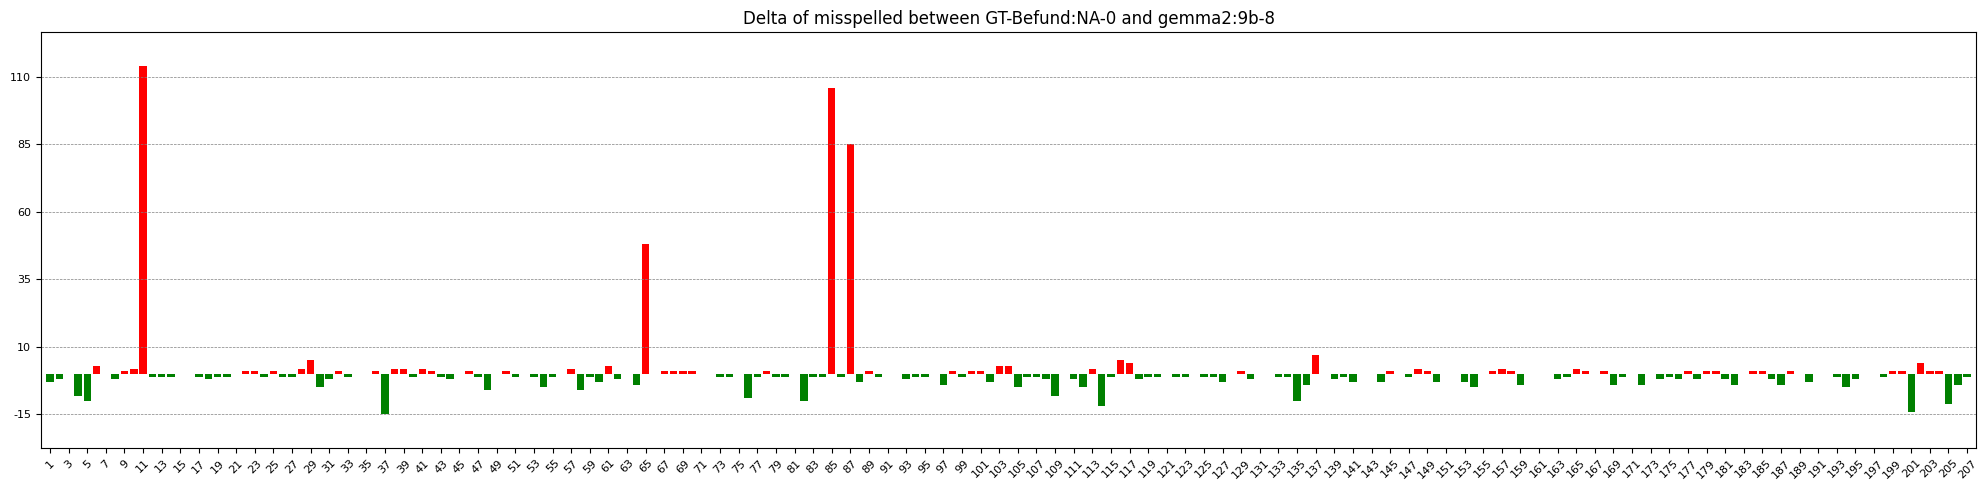

In [10]:
fig, ax = delta_bar_graph(gt_res[0], res1[0], "misspelled", 25)

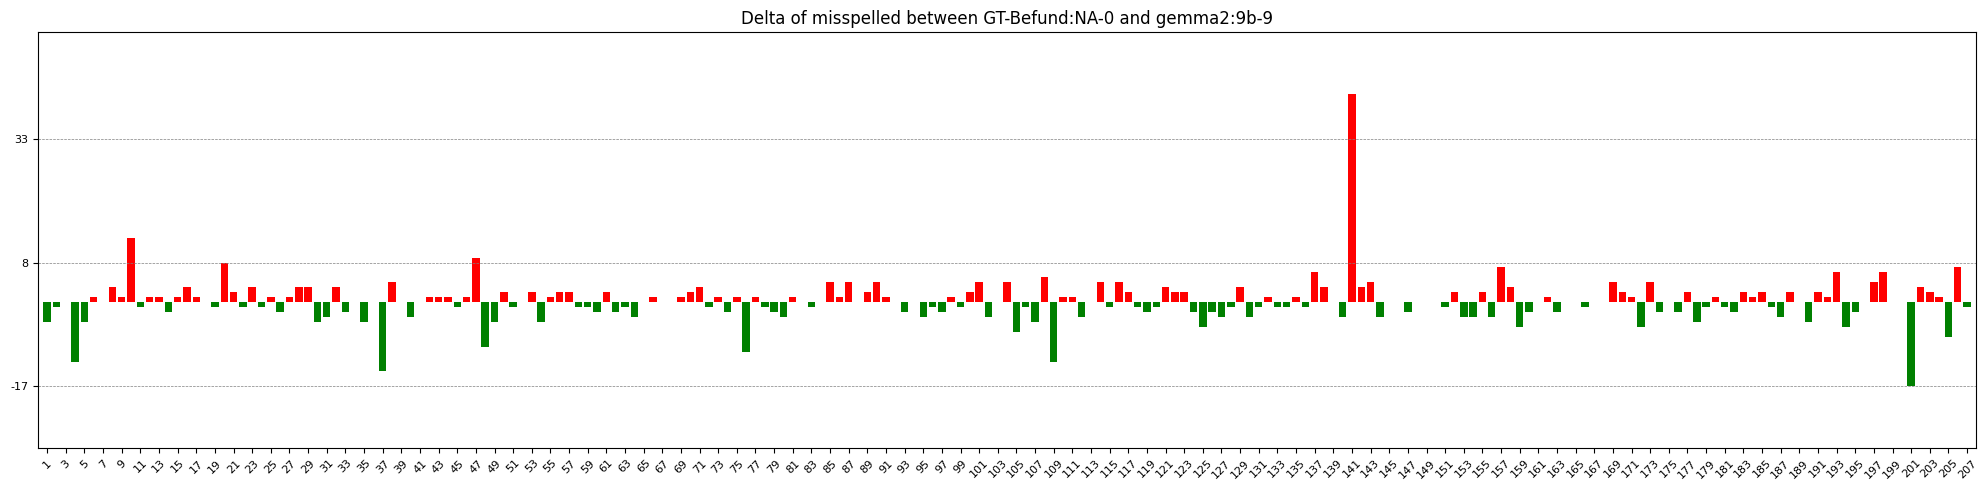

In [11]:
fig, ax = delta_bar_graph(gt_res[0], res2[0], "misspelled", 25)

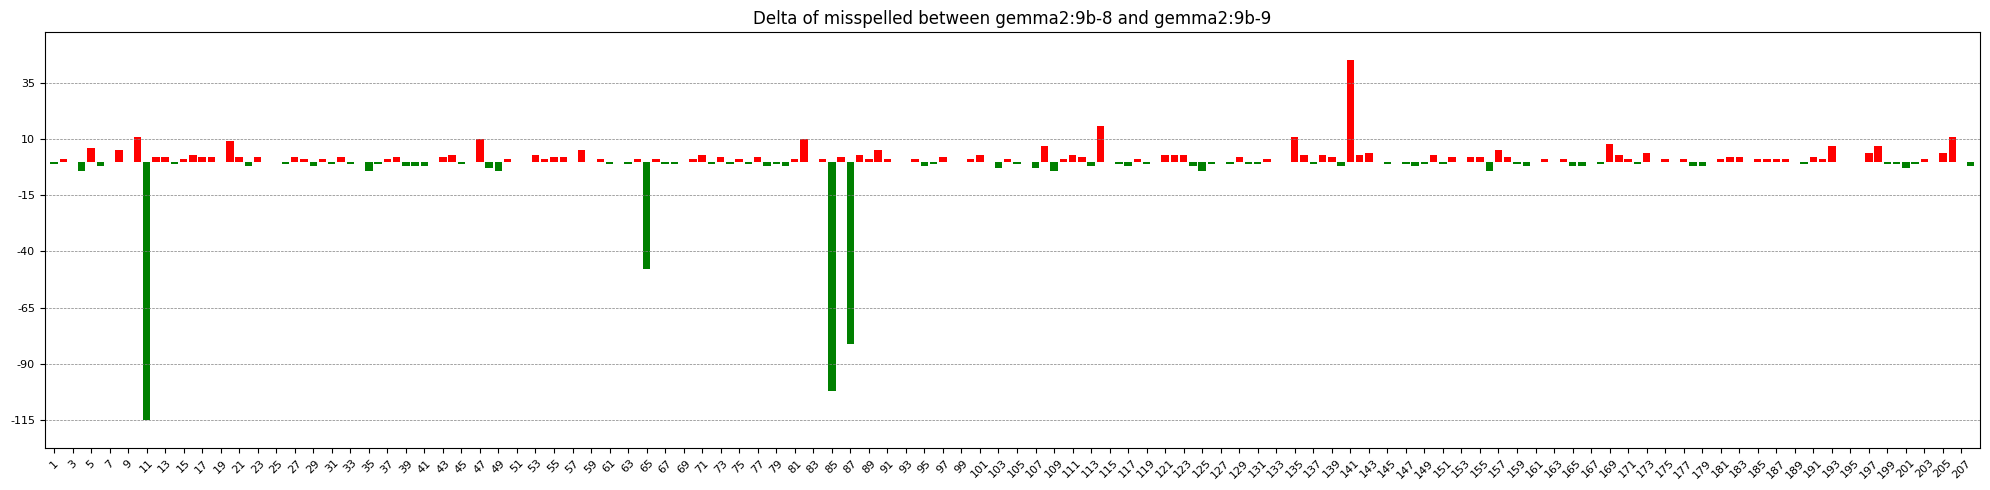

In [12]:
fig, ax = delta_bar_graph(res1[0], res2[0], "misspelled", 25)